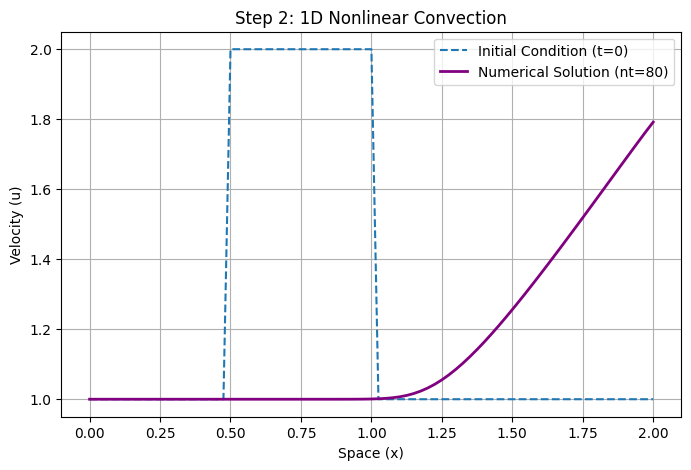

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
nx = 81                 # Number of grid points
dx = 2.0 / (nx - 1)     # Distance between grid points
nt = 80                 # Number of time steps
dt = 0.01               # Time step size

# --- 2. Initial Condition Setup ---
x = np.linspace(0, 2, nx)
u = np.ones(nx)
u[(x >= 0.5) & (x <= 1.0)] = 2.0  # Square wave profile

u_initial = u.copy()

# 2D array to store space profile at every time step
u_history = np.zeros((nt + 1, nx))
u_history[0, :] = u.copy()

# --- 3. Nonlinear Convection Solver Loop ---
for n in range(nt):
    un = u.copy()
    for i in range(1, nx):
        # Local wave speed is un[i] instead of constant c
        u[i] = un[i] - un[i] * (dt / dx) * (un[i] - un[i-1])
    u[0] = 1.0  # Boundary condition

    # Save step to history matrix
    u_history[n + 1, :] = u.copy()

# --- 4. Standard 2D Line Plot ---
plt.figure(figsize=(8, 5))
plt.plot(x, u_initial, label='Initial Condition (t=0)', linestyle='--')
plt.plot(x, u, label=f'Numerical Solution (nt={nt})', color='purple', linewidth=2)
plt.xlabel('Space (x)')
plt.ylabel('Velocity (u)')
plt.title('Step 2: 1D Nonlinear Convection')
plt.legend()
plt.grid(True)
plt.show()

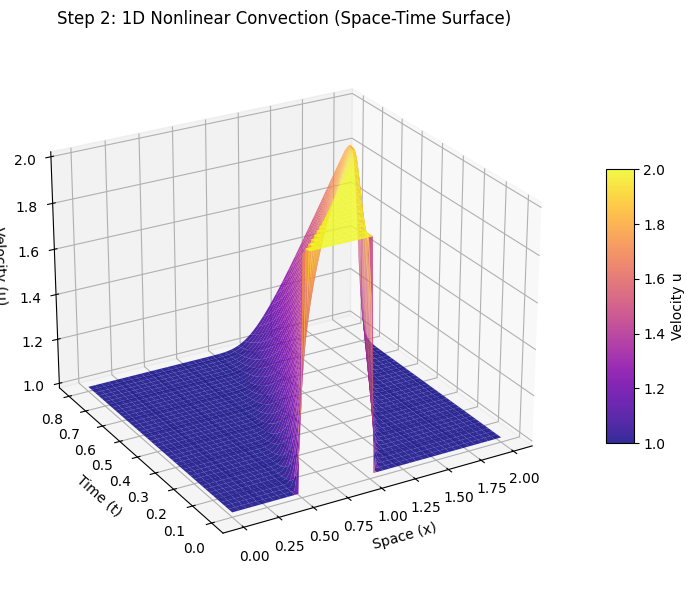

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate time vector and 2D spatial-temporal meshgrid
t_vec = np.linspace(0, nt * dt, nt + 1)
X, T = np.meshgrid(x, t_vec)

# --- 3D Surface Plot ---
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, u_history, cmap='plasma', edgecolor='none', alpha=0.85)

ax.set_xlabel('Space (x)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Velocity (u)')
ax.set_title('Step 2: 1D Nonlinear Convection (Space-Time Surface)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Velocity u')

# Set viewing angle to highlight the wave steepening / shock front
ax.view_init(elev=25, azim=-120)
plt.tight_layout()
plt.show()